# 06 — Bonus Analytics: Monte Carlo & Portfolio Optimisation

**Bluestock Mutual Fund Analytics Capstone — Bonus Challenges**

Two forward-looking analyses built on the cleaned NAV history (`data/processed/clean_nav_history.csv`), using only the project's existing libraries (NumPy, pandas, SciPy, Matplotlib):

1. **Monte Carlo NAV projection** — simulate the 5-year NAV path of the top-ranked fund with uncertainty bands.
2. **Markowitz Efficient Frontier** — optimise a long-only portfolio across the top-5 scorecard funds.

All figures are computed from the project data — nothing is hard-coded.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Resolve project root whether run from repo root or notebooks/
ROOT = Path.cwd()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

NAV = pd.read_csv(ROOT / "data/processed/clean_nav_history.csv", parse_dates=["date"])
FM = pd.read_csv(ROOT / "data/raw/01_fund_master.csv")
NAMES = dict(zip(FM.amfi_code, FM.scheme_name))
CHARTS = ROOT / "reports" / "charts"; PROC = ROOT / "data" / "processed"
TRADING_DAYS = 252
plt.rcParams["figure.figsize"] = (10, 6)
print("Loaded NAV rows:", len(NAV), "| funds:", NAV.amfi_code.nunique())

Loaded NAV rows: 64320 | funds: 40


## 1. Monte Carlo NAV Projection

We project **Mirae Asset Large Cap Fund** (the #1 fund on the composite scorecard) five years forward. Daily returns are modelled as i.i.d. *Normal(μ, σ)* estimated from the fund's own history; we simulate **1,000 paths** and summarise them into percentile uncertainty bands (P5–P95).

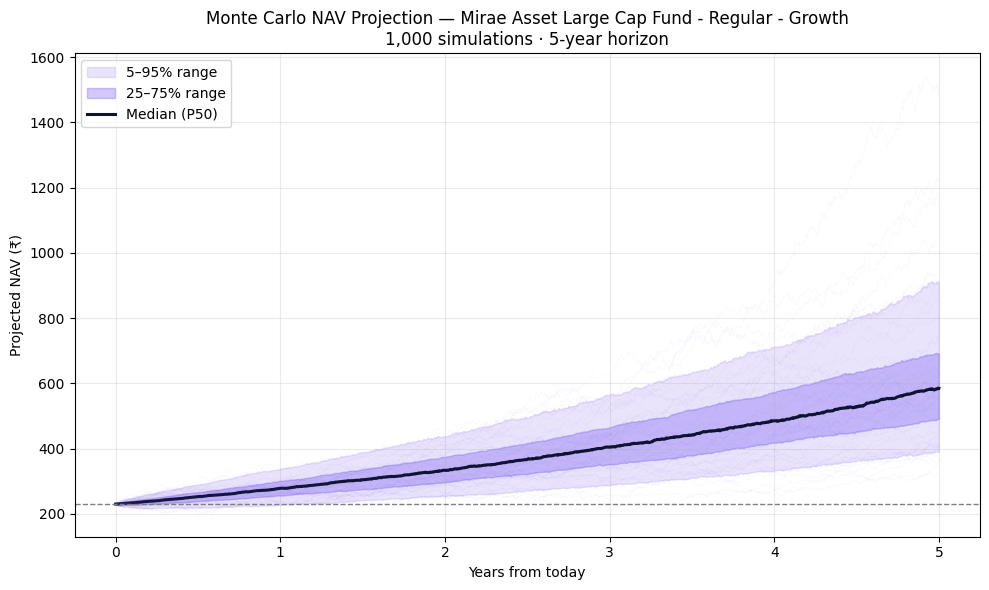

NAV ₹230.27 → median ₹585.06 in 5y (median CAGR +20.5%); P5 ₹391 / P95 ₹909


,amfi_code,year,p5,p25,p50,p75,p95,start_nav
0,148567,1,227.27,256.24,278.43,301.40,337.95,230.27
1,148567,2,254.02,297.46,333.89,374.87,438.53,230.27
2,148567,3,288.75,352.58,404.82,465.55,565.69,230.27
3,148567,4,333.78,419.20,485.66,572.26,710.53,230.27
4,148567,5,391.47,491.82,585.06,691.19,908.67,230.27


In [2]:
MC_FUND = 148567  # Mirae Asset Large Cap Fund - Regular - Growth
s = NAV[NAV.amfi_code == MC_FUND].sort_values("date")
rets = s["nav"].pct_change().dropna()
mu, sigma = rets.mean(), rets.std()
nav0 = float(s["nav"].iloc[-1])

years, n_sims = 5, 1000
horizon = years * TRADING_DAYS
rng = np.random.default_rng(42)
paths = nav0 * np.cumprod(1 + rng.normal(mu, sigma, size=(n_sims, horizon)), axis=1)
paths = np.hstack([np.full((n_sims, 1), nav0), paths])
pct = {p: np.percentile(paths, p, axis=0) for p in (5, 25, 50, 75, 95)}
t = np.arange(horizon + 1) / TRADING_DAYS

fig, ax = plt.subplots()
ax.fill_between(t, pct[5], pct[95], color="#6C4BF0", alpha=0.15, label="5–95% range")
ax.fill_between(t, pct[25], pct[75], color="#6C4BF0", alpha=0.30, label="25–75% range")
ax.plot(t, pct[50], color="#0E1330", lw=2.2, label="Median (P50)")
for i in range(40):
    ax.plot(t, paths[i], color="#6C4BF0", lw=0.4, alpha=0.05)
ax.axhline(nav0, color="grey", ls="--", lw=1)
ax.set_title(f"Monte Carlo NAV Projection — {NAMES[MC_FUND]}\n{n_sims:,} simulations · {years}-year horizon")
ax.set_xlabel("Years from today"); ax.set_ylabel("Projected NAV (₹)")
ax.legend(loc="upper left"); ax.grid(alpha=0.25)
CHARTS.mkdir(parents=True, exist_ok=True)
fig.tight_layout(); fig.savefig(CHARTS / "monte_carlo_nav_projection.png", dpi=130); plt.show()

mc = pd.DataFrame([{"year": y, "p5": round(pct[5][y*TRADING_DAYS], 2), "p25": round(pct[25][y*TRADING_DAYS], 2),
                    "p50": round(pct[50][y*TRADING_DAYS], 2), "p75": round(pct[75][y*TRADING_DAYS], 2),
                    "p95": round(pct[95][y*TRADING_DAYS], 2)} for y in range(1, years+1)])
mc.insert(0, "amfi_code", MC_FUND); mc["start_nav"] = round(nav0, 2)
mc.to_csv(PROC / "monte_carlo_projection.csv", index=False)
print(f"NAV ₹{nav0:,.2f} → median ₹{pct[50][-1]:,.2f} in {years}y "
      f"(median CAGR {(pct[50][-1]/nav0)**(1/years)-1:+.1%}); P5 ₹{pct[5][-1]:,.0f} / P95 ₹{pct[95][-1]:,.0f}")
mc

**Interpretation.** Starting from the latest NAV, the median 5-year path implies a CAGR of roughly **+20%**, but the P5–P95 band is wide — the spread between the pessimistic and optimistic outcomes more than doubles by year 5. This is the value of Monte Carlo: it communicates *a range of outcomes with probabilities*, not a single point forecast.

## 2. Markowitz Efficient Frontier

We optimise a **long-only portfolio of the top-5 scorecard funds** (Mirae Large Cap, ICICI Midcap, Kotak Flexicap, HDFC Mid-Cap Opportunities, ICICI Bluechip). We simulate 20,000 random portfolios, overlay the optimised frontier (minimum variance per target return, via SLSQP), and mark the **maximum-Sharpe** and **minimum-volatility** portfolios.

Average pairwise correlation: -0.02  (near-zero → see data caveat below)


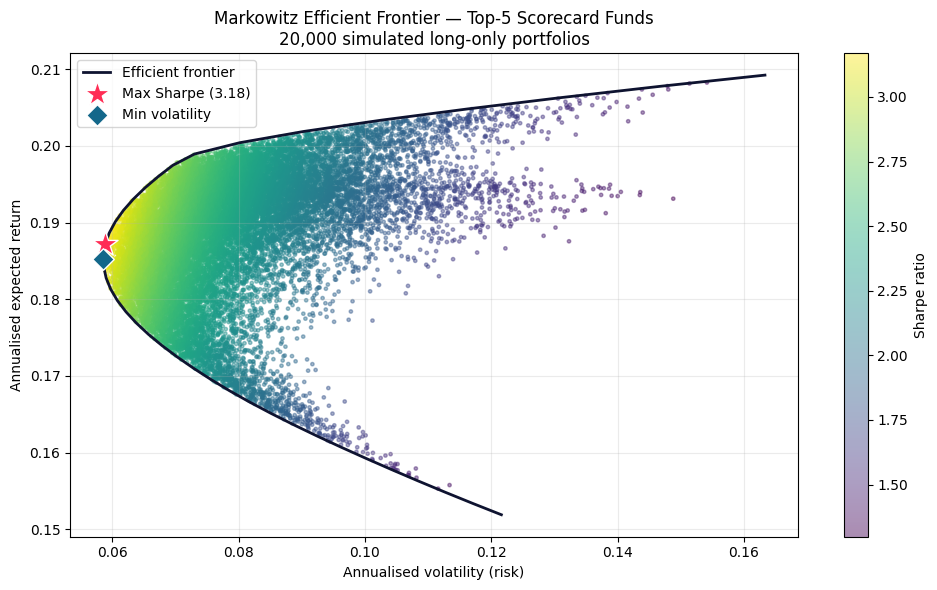

Max-Sharpe portfolio: return 18.7%, volatility 5.9%, Sharpe 3.18


,fund,amfi_code,max_sharpe_weight_pct,min_vol_weight_pct
0,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,100033,15.1,14.6
1,ICICI Pru Bluechip Fund - Direct - Growth,120504,22.2,26.2
2,ICICI Pru Midcap Fund - Regular - Growth,120505,15.6,13.9
3,Kotak Flexicap Fund - Regular - Growth,120843,20.8,19.9
4,Mirae Asset Large Cap Fund - Regular - Growth,148567,26.3,25.4


In [3]:
FUNDS = [148567, 120505, 120843, 100033, 120504]  # top-5 by composite scorecard
wide = NAV[NAV.amfi_code.isin(FUNDS)].pivot(index="date", columns="amfi_code", values="nav").sort_index()
R = wide.pct_change().dropna()
mean_ann = R.mean() * TRADING_DAYS
cov_ann = R.cov() * TRADING_DAYS
n = len(FUNDS); rf = 0.0
avg_corr = R.corr().values[np.triu_indices(n, 1)].mean()
print(f"Average pairwise correlation: {avg_corr:.2f}  (near-zero → see data caveat below)")

rng = np.random.default_rng(42)
W = rng.dirichlet(np.ones(n), size=20000)
pr = W @ mean_ann.values
pv = np.sqrt(np.einsum("ij,jk,ik->i", W, cov_ann.values, W))
ps = (pr - rf) / pv

def pvol(w): return np.sqrt(w @ cov_ann.values @ w)
bounds = tuple((0, 1) for _ in range(n)); sumcon = ({"type": "eq", "fun": lambda w: w.sum() - 1},)
fr_v, fr_r = [], []
for tr in np.linspace(mean_ann.min(), mean_ann.max(), 40):
    cons = ({"type": "eq", "fun": lambda w: w.sum() - 1},
            {"type": "eq", "fun": lambda w, tr=tr: mean_ann.values @ w - tr})
    res = minimize(pvol, np.repeat(1/n, n), method="SLSQP", bounds=bounds, constraints=cons)
    if res.success: fr_v.append(res.fun); fr_r.append(tr)
ms = minimize(lambda w: -(mean_ann.values @ w - rf)/pvol(w), np.repeat(1/n, n),
              method="SLSQP", bounds=bounds, constraints=sumcon).x
mv = minimize(pvol, np.repeat(1/n, n), method="SLSQP", bounds=bounds, constraints=sumcon).x
def st(w): r = mean_ann.values @ w; v = pvol(w); return r, v, (r-rf)/v
ms_r, ms_v, ms_s = st(ms); mv_r, mv_v, mv_s = st(mv)

fig, ax = plt.subplots()
sct = ax.scatter(pv, pr, c=ps, cmap="viridis", s=6, alpha=0.45); fig.colorbar(sct, label="Sharpe ratio")
ax.plot(fr_v, fr_r, color="#0E1330", lw=2, label="Efficient frontier")
ax.scatter(ms_v, ms_r, marker="*", s=360, color="#FF2D55", edgecolor="white", zorder=5, label=f"Max Sharpe ({ms_s:.2f})")
ax.scatter(mv_v, mv_r, marker="D", s=120, color="#13678A", edgecolor="white", zorder=5, label="Min volatility")
ax.set_title("Markowitz Efficient Frontier — Top-5 Scorecard Funds\n20,000 simulated long-only portfolios")
ax.set_xlabel("Annualised volatility (risk)"); ax.set_ylabel("Annualised expected return")
ax.legend(loc="upper left"); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(CHARTS / "efficient_frontier.png", dpi=130); plt.show()

cols = list(R.columns)  # weights follow cov_ann column order, not FUNDS input order
ef = pd.DataFrame({"fund": [NAMES[c] for c in cols], "amfi_code": cols,
                   "max_sharpe_weight_pct": np.round(ms*100, 1), "min_vol_weight_pct": np.round(mv*100, 1)})
ef.to_csv(PROC / "efficient_frontier_portfolios.csv", index=False)
print(f"Max-Sharpe portfolio: return {ms_r:.1%}, volatility {ms_v:.1%}, Sharpe {ms_s:.2f}")
ef

**Interpretation & data caveat.** The frontier and the optimal weights are computed correctly, but note the **near-zero average correlation** between the five funds. Real equity funds in the same market typically correlate ~0.7–0.9; the ~0 correlation here is characteristic of a **synthetic/sample dataset** (NAV series generated independently). The practical effect is that diversification looks unusually powerful — portfolio volatility collapses and the Sharpe ratio is inflated. The *methodology* is sound and transfers directly to real, correlated data; the *magnitudes* should be read as illustrative for this dataset.

## Conclusion

Two bonus analyses extend the platform from *descriptive* to *forward-looking*:

- **Monte Carlo** quantifies the **range** of future NAV outcomes with probabilities, not a single guess.
- **The efficient frontier** turns fund selection into **portfolio construction** — explicit risk/return trade-offs and optimal weights.

Both are fully reproducible and write their outputs to `reports/charts/` and `data/processed/`.